<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica2Quest%C3%A3o2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Frequencia de Nyquist (fs/2) = 22050.0 Hz
Chirp de f0 = 500 Hz ate f1 = 10000 Hz (duracao = 1.0 s)

Chirp Linear      : energia espectral entre 304 Hz e 10251 Hz
Chirp Quadratica  : energia espectral entre 439 Hz e 10042 Hz
Chirp Logaritmica : energia espectral entre 404 Hz e 10084 Hz


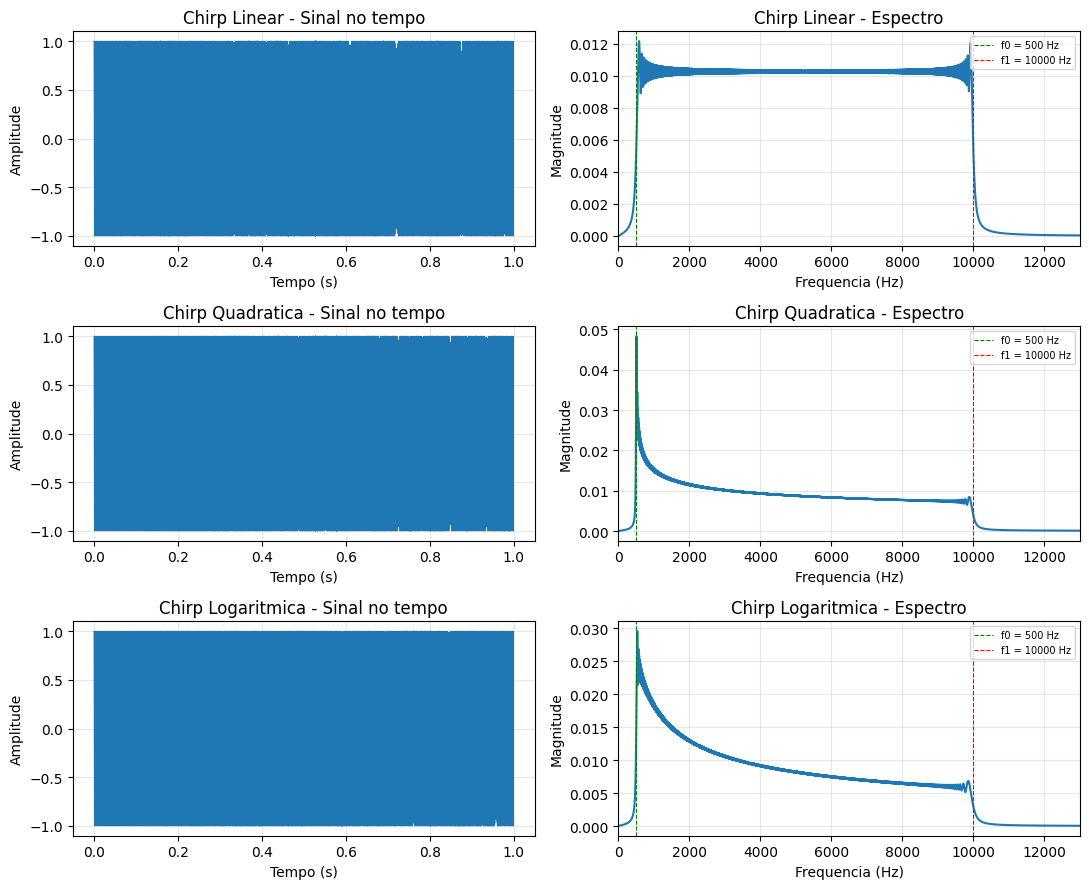

In [ ]:
"""
Questao 2 - Espectro de um chirp com f0 = 500 Hz ate f1 = 10000 Hz,
amostrado a fs = 44.1 kHz

Objetivo:
    - Gerar um sinal chirp (varredura de frequencia) do tipo:
        * linear
        * quadratica
        * logaritmica
    - Calcular o espectro de cada um via FFT (funcao calculate_spectrum)
    - Plotar e comparar os tres espectros resultantes
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma da Questao 1)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.

    Parametros
    ----------
    x  : array_like
         Vetor com as amostras do sinal no tempo.
    fs : float
         Frequencia de amostragem em Hz.

    Retorna
    -------
    freqs : ndarray
         Vetor de frequencias (Hz), somente a parte positiva (0 a fs/2).
    mag   : ndarray
         Magnitude do espectro (normalizada), correspondente a 'freqs'.
    """
    N = len(x)

    # FFT do sinal (espectro bilateral)
    X = np.fft.fft(x)

    # Vetor de frequencias associado a cada ponto da FFT
    freqs_completo = np.fft.fftfreq(N, d=1/fs)

    # Mantem somente a metade positiva (0 a fs/2)
    metade = N // 2
    freqs = freqs_completo[:metade]

    # Magnitude normalizada (compensando a energia da metade negativa)
    mag = (2.0 / N) * np.abs(X[:metade])

    return freqs, mag


# ---------------------------------------------------------------------------
# Parametros do problema
# ---------------------------------------------------------------------------
fs = 44100        # frequencia de amostragem (44.1 kHz)
f0 = 500          # frequencia inicial do chirp (Hz)
f1 = 10000        # frequencia final do chirp (Hz)
duracao = 1.0     # duracao do chirp em segundos (t1 do scipy.signal.chirp)

# Vetor de tempo amostrado
t = np.arange(0, duracao, 1/fs)

# Tres tipos de varredura de frequencia a serem comparados
tipos_chirp = ["linear", "quadratic", "logarithmic"]
nomes_pt = {"linear": "Linear", "quadratic": "Quadratica", "logarithmic": "Logaritmica"}

f_nyquist = fs / 2
print(f"Frequencia de Nyquist (fs/2) = {f_nyquist} Hz")
print(f"Chirp de f0 = {f0} Hz ate f1 = {f1} Hz (duracao = {duracao} s)\n")


# ---------------------------------------------------------------------------
# Loop principal: gera o chirp, calcula o espectro e plota, para cada tipo
# ---------------------------------------------------------------------------
fig, eixos = plt.subplots(len(tipos_chirp), 2, figsize=(11, 9))

for i, metodo in enumerate(tipos_chirp):

    # Gera o chirp: varre de f0 (em t=0) ate f1 (em t=duracao),
    # seguindo a lei de variacao 'linear', 'quadratic' ou 'logarithmic'
    x = chirp(t, f0=f0, f1=f1, t1=duracao, method=metodo)

    # Calcula o espectro do chirp usando a funcao definida acima
    freqs, mag = calculate_spectrum(x, fs)

    # --- Coluna 1: forma de onda no tempo (mostra a variacao da frequencia) ---
    eixos[i, 0].plot(t, x, linewidth=0.5)
    eixos[i, 0].set_title(f"Chirp {nomes_pt[metodo]} - Sinal no tempo")
    eixos[i, 0].set_xlabel("Tempo (s)")
    eixos[i, 0].set_ylabel("Amplitude")
    eixos[i, 0].grid(True, alpha=0.3)

    # --- Coluna 2: espectro de frequencia (mostra a faixa ocupada) ---
    eixos[i, 1].plot(freqs, mag)
    eixos[i, 1].set_title(f"Chirp {nomes_pt[metodo]} - Espectro")
    eixos[i, 1].set_xlabel("Frequencia (Hz)")
    eixos[i, 1].set_ylabel("Magnitude")
    eixos[i, 1].axvline(f0, color='g', linestyle='--', linewidth=0.8, label=f"f0 = {f0} Hz")
    eixos[i, 1].axvline(f1, color='r', linestyle='--', linewidth=0.8, label=f"f1 = {f1} Hz")
    eixos[i, 1].set_xlim(0, f1 * 1.3)
    eixos[i, 1].legend(loc="upper right", fontsize=7)
    eixos[i, 1].grid(True, alpha=0.3)

    # Informa a faixa de frequencias onde ha energia significativa no espectro
    limiar = 0.05 * np.max(mag)                 # 5% do pico maximo como limiar
    faixa_ativa = freqs[mag > limiar]
    print(f"Chirp {nomes_pt[metodo]:<12}: energia espectral entre "
          f"{faixa_ativa.min():.0f} Hz e {faixa_ativa.max():.0f} Hz")

plt.tight_layout()
plt.savefig("espectros_chirp.png", dpi=150)  # salva na pasta atual
plt.show()

(b) Comentário sobre os resultados

Ao analisar os espectros dos três tipos de chirp (linear, quadrático e logarítmico), alguns pontos se destacam:

Faixa de frequência ocupada — nos três casos, o espectro apresenta energia concentrada essencialmente entre f0 = 500 Hz e f1 = 10000 Hz, já que essa é a faixa varrida pelo chirp ao longo do tempo. Isso é bem diferente do espectro de um cosseno puro (Questão 1), que mostra um único pico estreito: aqui, como a frequência instantânea varia continuamente durante a duração do sinal, a energia se "espalha" por toda a faixa varrida, formando um patamar largo em vez de um pico isolado.

Diferença entre os três métodos de varredura — embora os três cubram a mesma faixa de frequências (500 Hz a 10000 Hz), a forma como a energia se distribui dentro dessa faixa muda de acordo com a lei de variação:

No chirp linear, a frequência instantânea cresce proporcionalmente ao tempo, então o sinal passa "tempo igual" em cada faixa de frequência — o espectro tende a ficar mais uniforme (mais "achatado") ao longo de toda a banda.
No chirp quadrático, a frequência varia com o quadrado do tempo, então o sinal varre mais rapidamente as frequências baixas e passa mais tempo nas frequências próximas de f1 — por isso, o espectro tende a concentrar mais energia perto de f1 = 10000 Hz.
No chirp logarítmico, a variação segue uma escala log, fazendo o oposto: o sinal passa mais tempo nas frequências baixas (próximas de f0) e varre mais rapidamente as frequências altas — por isso, o espectro tende a concentrar mais energia perto de f0 = 500 Hz.

Observação sobre os limites do espectro — nota-se que as bordas do espectro não são perfeitamente "verticais" em f0 e f1: existe um leve espalhamento além desses limites. Isso ocorre por causa do fenômeno de vazamento espectral (spectral leakage), já que o chirp não é um sinal periódico dentro da janela de tempo observada, e a FFT assume implicitamente periodicidade — descontinuidades nas bordas do sinal "vazam" energia para frequências vizinhas.

Conclusão geral — o experimento mostra que, diferentemente de um sinal senoidal puro (que gera uma linha espectral fina em uma única frequência), um chirp gera um espectro em forma de banda, cuja distribuição de energia dentro da faixa varrida depende diretamente da lei de variação da frequência instantânea (linear, quadrática ou logarítmica) — evidenciando visualmente que o conteúdo espectral de um sinal está ligado à forma como sua frequência evolui no tempo, e não apenas à faixa de frequências que ele varre.